In [1]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    !git clone https://github.com/SantiagoEzequielDrelewicz/TP-LMC.git
    %cd TP-LMC
    # !pip install -r requirements.txt

Cloning into 'TP-LMC'...
remote: Enumerating objects: 91, done.
remote: Counting objects: 100% (24/24), done.
remote: Compressing objects: 100% (24/24), done.
remote: Total 91 (delta 11), reused 1 (delta 0), pack-reused 67 (from 1)
Receiving objects: 100% (91/91), 54.32 MiB | 30.71 MiB/s, done.
Resolving deltas: 100% (33/33), done.
/content/TP-LMC


In [2]:
!pip install -r requirements.txt # descomentar y ejecutar si se corre localmente y no se usa un entorno virtual.

In [3]:
import os
from pathlib import Path
import zipfile # para descomprimir los datasets

import pandas as pd

# Carga de los datasets

In [4]:
def cargar_dataset(letra: str) -> pd.DataFrame:
    """Descomprime el dataset correspondiente a la letra dada."""
    with zipfile.ZipFile(f"datos/crudos/datasets.zip", "r") as z:
        with z.open(f"datasets/Dataset_{letra}.csv") as f:
            df = pd.read_csv(f, sep=";")
    return df

In [5]:
df_A = cargar_dataset("A")
df_A

/tmp/ipykernel_9379/3506033332.py:5: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f, sep=";")


,ID,PLAN,GRUPPO,TARIFA DETALLE,FECHA ACTIVACION,TOTAL ACTIVA,FECHA LETT ANT,FECHA LETT ACT,FECHA BAJA,DIAS LEIDOS,...,FACTOR ESTACIONAL,ENERGIA MEDIDORES,CONSUMO ESTIMADO,CONSUMO TOTAL FINAL,REFERENCIA,REAL MES CALCULADO,REAL ACUMULADO ANO,TOTAL BALANCE ANO,AJUSTE,ENERGIA ENTREGADA
0,9,7,T1,T1-R,24/9/1995,895.0,22/8/2025,22/10/2025,NaN,61.0,...,"0,951431459",0.0,419.0,"418,7858144",202511,0,7804,7997,0,"418,7858144"
1,24,7,T1,T1-R,24/9/1995,1254.0,22/8/2025,22/10/2025,NaN,61.0,...,"0,951431459",0.0,587.0,"586,7680573",202511,0,4575,4345,0,"586,7680573"
2,229,7,T1,T1-R,24/9/1995,953.0,22/8/2025,22/10/2025,NaN,61.0,...,"0,951431459",0.0,446.0,"445,9250069",202511,0,6395,6245,0,"445,9250069"
3,302,7,T1,T1-R,24/9/1995,1239.0,22/8/2025,22/10/2025,NaN,61.0,...,"0,951431459",0.0,580.0,"579,7493007",202511,0,5586,5639,0,"579,7493007"
4,361,7,T1,T1-R,24/9/1995,1233.0,22/8/2025,22/10/2025,NaN,61.0,...,"0,951431459",0.0,577.0,"576,941798",202511,0,5135,5085,0,"576,941798"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
177865,4603,7,T1,T1-G,24/9/1995,1275.0,22/10/2025,2/12/2025,NaN,41.0,...,"1,287038217",1161.0,0.0,"1222,883856",202512,987,13901,13989,-88,"1134,731648"
177866,7120,7,T1,T1-G,24/9/1995,600.0,22/10/2025,2/12/2025,NaN,41.0,...,"1,287038217",546.0,0.0,"575,4747556",202512,400,4424,4324,100,"675,0047745"
177867,2694,7,T1,T1-G,24/9/1995,1661.0,22/10/2025,2/12/2025,NaN,41.0,...,"1,287038217",1512.0,0.0,"1593,105948",202512,1436,15233,15676,-443,"1149,684167"
177868,9194,7,T1,T1-G,24/9/1995,4320.0,22/10/2025,2/12/2025,NaN,41.0,...,"1,287038217",3933.0,0.0,"4143,41824",202512,2986,29232,28746,485,"4628,542404"


## Union de los datasets

In [6]:
def cargar_dataset_completo() -> pd.DataFrame:
    """Concatena los datasets A, B, C y D."""
    df_completo = pd.DataFrame()
    for letra in ["A", "B", "C", "D"]:
        df_letra =  cargar_dataset(letra)
        df_completo = pd.concat([df_completo, df_letra])
    return df_completo

In [7]:
df_completo = cargar_dataset_completo()
df_completo

/tmp/ipykernel_9379/3506033332.py:5: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f, sep=";")
/tmp/ipykernel_9379/3506033332.py:5: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f, sep=";")
/tmp/ipykernel_9379/3506033332.py:5: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f, sep=";")
/tmp/ipykernel_9379/3506033332.py:5: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f, sep=";")


,ID,PLAN,GRUPPO,TARIFA DETALLE,FECHA ACTIVACION,TOTAL ACTIVA,FECHA LETT ANT,FECHA LETT ACT,FECHA BAJA,DIAS LEIDOS,...,FACTOR ESTACIONAL,ENERGIA MEDIDORES,CONSUMO ESTIMADO,CONSUMO TOTAL FINAL,REFERENCIA,REAL MES CALCULADO,REAL ACUMULADO ANO,TOTAL BALANCE ANO,AJUSTE,ENERGIA ENTREGADA
0,9,7,T1,T1-R,24/9/1995,895.0,22/8/2025,22/10/2025,NaN,61.0,...,"0,951431459",0.0,419.0,"418,7858144",202511,0,7804,7997,0,"418,7858144"
1,24,7,T1,T1-R,24/9/1995,1254.0,22/8/2025,22/10/2025,NaN,61.0,...,"0,951431459",0.0,587.0,"586,7680573",202511,0,4575,4345,0,"586,7680573"
2,229,7,T1,T1-R,24/9/1995,953.0,22/8/2025,22/10/2025,NaN,61.0,...,"0,951431459",0.0,446.0,"445,9250069",202511,0,6395,6245,0,"445,9250069"
3,302,7,T1,T1-R,24/9/1995,1239.0,22/8/2025,22/10/2025,NaN,61.0,...,"0,951431459",0.0,580.0,"579,7493007",202511,0,5586,5639,0,"579,7493007"
4,361,7,T1,T1-R,24/9/1995,1233.0,22/8/2025,22/10/2025,NaN,61.0,...,"0,951431459",0.0,577.0,"576,941798",202511,0,5135,5085,0,"576,941798"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
177889,38255,64,T1,T1-R,2/7/2003,1788.0,18/7/2025,17/9/2025,14/11/2025,61.0,...,"0,805124192",0.0,330.0,"330,3912914",202511,498,6764,8133,-1369,"-1038,670412"
177890,38255,64,T1,T1-R,2/7/2003,1788.0,18/7/2025,17/9/2025,14/11/2025,61.0,...,"0,805122685",0.0,330.0,"330,3906729",202511,498,6764,8133,-1369,"-1038,670412"
177891,38802,46,T1,T1-R,14/9/2002,1499.0,18/6/2025,18/8/2025,17/10/2025,61.0,...,"0,703439837",0.0,294.0,"293,8648748",202510,442,5462,6597,-1134,"-840,6172079"
177892,39734,64,T1,T1-R,26/5/2003,1486.0,17/7/2025,16/9/2025,14/11/2025,61.0,...,"0,800373321",0.0,273.0,"272,9666652",202511,390,4906,6058,-1151,"-878,2512804"


In [8]:
df_completo.info()

<class 'pandas.core.frame.DataFrame'>
Index: 711829 entries, 0 to 177893
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   ID                              711829 non-null  int64  
 1   PLAN                            711829 non-null  int64  
 2   GRUPPO                          711829 non-null  object 
 3   TARIFA DETALLE                  711829 non-null  object 
 4   FECHA ACTIVACION                711829 non-null  object 
 5   TOTAL ACTIVA                    710728 non-null  float64
 6   FECHA LETT ANT                  710728 non-null  object 
 7   FECHA LETT ACT                  710728 non-null  object 
 8   FECHA BAJA                      4215 non-null    object 
 9   DIAS LEIDOS                     710728 non-null  float64
 10  PROMEDIO CONSUMO                710728 non-null  object 
 11  DIAS LEIDOS MES                 711829 non-null  int64  
 12  DIAS ESTIMAR         

## **Columnas a utilizar**
- ID: n° de cliente
- FECHA ACTIVACION: fecha de alta del cliente
- TOTAL ACTIVA consumo de energia (kWh) entre FECHA LETT ANT y FECHA LETT ACT
- FECHA LETT ANT: fecha de la penultima lectura
- FECHA LETT ACT: fecha de la última lectura
- FECHA BAJA: fecha de baja del cliente
- DIAS LEIDOS: dias entre FECHA LETT ANT y FECHA LETT ACT
- PROMEDIO CONSUMO = TOTAL ACTIVA / DIAS LEIDOS
- DIAS LEIDOS MES: dias de lectura en el mes de REFERENCIA
- DIAS ESTIMAR = dias entre max(FECHA LETT ACT, fecha correspondiente a DIAS LEIDOS MES) y ultimo dia del mes de REFERENCIA
- CONSUMO LEIDO = cosumo de energía leido en el mes de REFERENCIA
- DEMANDA PERIODO LEIDO = demanda total comprendida entre FECHA LETT ANT y FECHA LETT ACT
- DEMANDA PERIODO DIAS MEDIDORES: demanda total entre max(FECHA LETT ACT, la fecha correspondiente al día DIAS LEIDOS MES) y el último día del mes de REFERENCIA
- FACTOR ESTACIONAL = $\frac{
    \frac{\text{DEMANDA PERIODO DIAS MEDIDORES}}
         {\text{DIAS ESTIMAR}}
  }{
    \frac{\text{DEMANDA PERIODO LEIDO}}
         {\text{DIAS LEIDOS}}
  }$
- ENERGIA MEDIDORES:
  ```
  Si (DIAS LEIDOS > 0 ) entonces
    ENERGIA MEDIDORES = FACTOR ESTACIONAL × PROMEDIO CONSUMO × DIAS ESTIMAR,
  sino
    ENERGIA MEDIDORES = 0
    
  ```
- CONSUMO ESTIMADO:
  ```
  Si (DIAS LEIDOS = 0 ) entonces
    CONSUMO ESTIMADO = FACTOR ESTACIONAL × PROMEDIO CONSUMO × DIAS ESTIMAR,
  sino
    CONSUMO ESTIMADO = 0
    
  ```
- CONSUMO TOTAL FINAL = ENERGIA MEDIDORES + CONSUMO ESTIMADO + CONSUMO LEIDO

In [9]:
COLUMNAS_RELEVANTES = [
    "ID",
    "FECHA ACTIVACION",
    "TOTAL ACTIVA",
    "FECHA LETT ANT",
    "FECHA LETT ACT",
    "FECHA BAJA",
    "DIAS LEIDOS",
    "PROMEDIO CONSUMO",
    "DIAS LEIDOS MES",
    "DIAS ESTIMAR",
    "CONSUMO LEIDO",
    "DEMANDA PERIODO LEIDO",
    "DEMANDA PERIODO DIAS MEDIDORES",
    "FACTOR ESTACIONAL",
    "ENERGIA MEDIDORES",
    "CONSUMO ESTIMADO",
    "CONSUMO TOTAL FINAL",
    "REFERENCIA",
]

# Modelo

$$
c(t) = B + \beta_c \cdot HDD(t) + \beta_f \cdot CDD(t)
$$

- $B$: consumo base del cliente  
- $HDD(t)$: frío instantáneo  
- $CDD(t)$: calor instantáneo  

---

$$
\beta_f = \frac{\partial c}{\partial HDD(t)}
$$

$$
\beta_c = \frac{\partial c}{\partial CDD(t)}
$$

---

$$
C\Big|_{t_0}^{t_1} = \int_{t_0}^{t_1} c(t)\,dt
$$

$$
C = \int_{t_0}^{t_1}
\left(
B + \beta_f \cdot HDD(t) + \beta_c \cdot CDD(t)
\right)\,dt
$$

$$
C =
B \cdot \Delta t
+
\beta_f \cdot \int_{t_0}^{t_1} HDD(t)\,dt
+
\beta_c \cdot \int_{t_0}^{t_1} CDD(t)\,dt
$$

---

$$
B_{\text{cliente}}
=
\min\left(
[C\!ONSUMO\ TOTAL\ FINAL]_{\text{cliente-2025}}
\right)
$$

---

$$
C_{\text{estimado}}
=
\int_{t_0}^{t_1}
\left(
B + \beta_c \cdot HDD(t) + \beta_f \cdot CDD(t)
\right)\,dt
$$

---

$$
\frac{\partial C(\text{mes})}{\partial HDD(\text{mes})}
=
\beta_c
$$

$$
\frac{\partial C(\text{mes})}{\partial CDD(\text{mes})}
=
\beta_f
$$

In [10]:
df_completo.describe()

,ID,PLAN,TOTAL ACTIVA,DIAS LEIDOS,DIAS LEIDOS MES,DIAS ESTIMAR,CONSUMO LEIDO,DEMANDA PERIODO LEIDO,DEMANDA PERIODO DIAS MEDIDORES,ENERGIA MEDIDORES,CONSUMO ESTIMADO,REFERENCIA,REAL MES CALCULADO,REAL ACUMULADO ANO,TOTAL BALANCE ANO,AJUSTE
count,711829.000000,711829.000000,710728.000000,710728.000000,711829.000000,711829.000000,711829.000000,7.107280e+05,6.979730e+05,697973.000000,699074.000000,711829.000000,711829.000000,711829.000000,711829.000000,711829.000000
mean,19999.992972,54.148267,1202.000477,59.519424,7.125166,23.205582,143.444646,3.470958e+09,1.400490e+09,186.230992,301.001282,202507.146317,297.542633,3473.925160,3476.643740,-2.745919
std,11545.129564,20.617158,1296.758233,7.389018,9.600803,9.648897,313.594829,6.071522e+08,5.795530e+08,423.157758,563.931931,3.287131,556.905010,4528.935099,4568.297992,493.056657
min,1.000000,6.000000,1.000000,5.000000,0.000000,0.000000,0.000000,2.544481e+08,0.000000e+00,0.000000,0.000000,202501.000000,0.000000,0.000000,0.000000,-28539.000000
25%,10004.000000,50.000000,692.000000,59.000000,0.000000,18.000000,0.000000,3.096786e+09,1.023775e+09,0.000000,0.000000,202505.000000,0.000000,1387.000000,1296.000000,0.000000
50%,20001.000000,59.000000,937.000000,61.000000,2.000000,28.000000,21.000000,3.509140e+09,1.538967e+09,20.000000,0.000000,202507.000000,0.000000,2924.000000,2893.000000,0.000000
75%,29997.000000,68.000000,1335.000000,62.000000,13.000000,30.000000,197.000000,3.894814e+09,1.850257e+09,284.000000,481.000000,202510.000000,461.000000,4421.000000,4475.000000,0.000000
max,40000.000000,79.000000,96000.000000,423.000000,31.000000,31.000000,40353.000000,2.446803e+10,2.161943e+09,40610.000000,44976.000000,202512.000000,49600.000000,405902.000000,418068.000000,95280.000000


# Limpieza del dataset

## Valores nulos

In [11]:
# Información general
print("Shape del dataframe:")
print(df_completo.shape)

print("\nCantidad total de valores:")
print(df_completo.size)

print("\nCantidad total de nulos:")
print(df_completo.isnull().sum().sum())

print("\nPorcentaje total de nulos:")
print(round(df_completo.isnull().sum().sum() / df_completo.size * 100, 2), "%")

# Nulos por columna
nulos_columna = pd.DataFrame({
    "cant_nulos": df_completo.isnull().sum(),
    "porcentaje_nulos": round(df_completo.isnull().mean() * 100, 2)
})

# Ordenar de mayor a menor
nulos_columna = nulos_columna.sort_values(by="cant_nulos", ascending=False)

print("\nNulos por columna:")
display(nulos_columna)

# Filas con al menos un nulo
filas_con_nulos = df_completo.isnull().any(axis=1).sum()

print("\nCantidad de filas con al menos un nulo:")
print(filas_con_nulos)

print("\nPorcentaje de filas con al menos un nulo:")
print(round(filas_con_nulos / len(df_completo) * 100, 2), "%")

Shape del dataframe:
(711829, 26)

Cantidad total de valores:
18507554

Cantidad total de nulos:
768543

Porcentaje total de nulos:
4.15 %

Nulos por columna:


,cant_nulos,porcentaje_nulos
FECHA BAJA,707614,99.41
FACTOR ESTACIONAL,13856,1.95
ENERGIA MEDIDORES,13856,1.95
DEMANDA PERIODO DIAS MEDIDORES,13856,1.95
CONSUMO ESTIMADO,12755,1.79
DEMANDA PERIODO LEIDO,1101,0.15
DIAS LEIDOS,1101,0.15
FECHA LETT ACT,1101,0.15
FECHA LETT ANT,1101,0.15
TOTAL ACTIVA,1101,0.15



Cantidad de filas con al menos un nulo:
707614

Porcentaje de filas con al menos un nulo:
99.41 %


## FECHA DE BAJA
Dropeamos las filas que tenga valores no nulos de fecha de baja y la eliminamos para el análisis. Y ahora si podemos eliminar el resto de las filas que tienen valores nulos

Son todos datos de 2025, entonces solo nos importan los meses

## Errores de escritura:
PROMEDIO CONSUMO, FACTOR ESTACIONAL y CONSUMO TOTAL FINAL tienen una coma en vez de punto lo cual los convierte a tipo object.

In [12]:
def coma_num_to_float(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    for col in cols:
      df[col] = df[col].astype(str).str.replace(",", ".").astype(float)
    return df[cols]

## REFERENCIA
El periodo de refencia Está como int y todos sus datos corresponden a 2025, así que solo nos importa su mes

In [13]:
df_completo["REFERENCIA"].astype(str).str[:4].unique()

array(['2025'], dtype=object)

In [14]:
RUTA_GUARDADO = "datos/procesados/datos_limpios.csv.gz"

def limpiar_dataset(df: pd.DataFrame, *, guardar: bool = False, filtrar_columnas: bool = False) -> pd.DataFrame:
    """Realiza la limpieza del dataset completo."""
    df_limpio = df.copy()

    # Filtrar columnas relevantes
    if filtrar_columnas:
        df_limpio = df_limpio[COLUMNAS_RELEVANTES]

    # Filtrar filas con fecha de baja mp nula y luego eliminarla, ya que no aporta información relevante para el análisis
    df_limpio = df_limpio[df_limpio["FECHA BAJA"].isnull()].reset_index(drop=True).drop(columns=["FECHA BAJA"])

    # Eliminar filas con valores nulos

    df_limpio.dropna(inplace=True)

    # Convertir columnas con números en formato de coma a float
    columnas_con_coma_num = ["PROMEDIO CONSUMO", "FACTOR ESTACIONAL", "CONSUMO TOTAL FINAL"]
    df_limpio[columnas_con_coma_num] = coma_num_to_float(df_limpio, columnas_con_coma_num)

    # Extraer el mes de la columna REFERENCIA y convertirlo a int
    df_limpio["REFERENCIA"] = df_limpio["REFERENCIA"].astype(str).str[4:6].astype(int)

    if guardar:
        df_limpio.to_csv(RUTA_GUARDADO, index=False, compression="gzip")

    return df_limpio

In [15]:
df_limpio = limpiar_dataset(df_completo)
df_limpio

,ID,PLAN,GRUPPO,TARIFA DETALLE,FECHA ACTIVACION,TOTAL ACTIVA,FECHA LETT ANT,FECHA LETT ACT,DIAS LEIDOS,PROMEDIO CONSUMO,...,FACTOR ESTACIONAL,ENERGIA MEDIDORES,CONSUMO ESTIMADO,CONSUMO TOTAL FINAL,REFERENCIA,REAL MES CALCULADO,REAL ACUMULADO ANO,TOTAL BALANCE ANO,AJUSTE,ENERGIA ENTREGADA
0,9,7,T1,T1-R,24/9/1995,895.0,22/8/2025,22/10/2025,61.0,14.672131,...,0.951431,0.0,419.0,418.785814,11,0,7804,7997,0,"418,7858144"
1,24,7,T1,T1-R,24/9/1995,1254.0,22/8/2025,22/10/2025,61.0,20.557377,...,0.951431,0.0,587.0,586.768057,11,0,4575,4345,0,"586,7680573"
2,229,7,T1,T1-R,24/9/1995,953.0,22/8/2025,22/10/2025,61.0,15.622951,...,0.951431,0.0,446.0,445.925007,11,0,6395,6245,0,"445,9250069"
3,302,7,T1,T1-R,24/9/1995,1239.0,22/8/2025,22/10/2025,61.0,20.311475,...,0.951431,0.0,580.0,579.749301,11,0,5586,5639,0,"579,7493007"
4,361,7,T1,T1-R,24/9/1995,1233.0,22/8/2025,22/10/2025,61.0,20.213115,...,0.951431,0.0,577.0,576.941798,11,0,5135,5085,0,"576,941798"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
707609,32713,7,T1,T1-G,24/9/1995,3372.0,22/10/2025,2/12/2025,41.0,82.243902,...,1.287038,3070.0,0.0,3234.168126,12,2469,24085,24008,77,"3311,380497"
707610,34749,7,T1,T1-G,24/9/1995,872.0,22/10/2025,2/12/2025,41.0,21.268293,...,1.287038,794.0,0.0,836.356645,12,587,5939,5806,133,"969,1322582"
707611,37589,7,T1,T1-G,24/9/1995,550.0,22/10/2025,2/12/2025,41.0,13.414634,...,1.287038,501.0,0.0,527.518526,12,434,5202,5257,-55,"472,5714829"
707612,38053,7,T1,T1-G,24/9/1995,765.0,22/10/2025,2/12/2025,41.0,18.658537,...,1.287038,696.0,0.0,733.730313,12,578,6644,6665,-22,"712,0904052"


# Cargar dataset limpio

In [16]:
def cargar_dataset_limpio() -> pd.DataFrame:
    """Carga el dataset completo y limpio."""
    # chequear si ya existe el dataset limpio guardado, sino limpiarlo y guardarlo
    if os.path.exists(RUTA_GUARDADO):
        print("Cargando dataset limpio desde el archivo guardado...")
        df = pd.read_csv(RUTA_GUARDADO)
    else:
        df_completo = cargar_dataset_completo()
        df = limpiar_dataset(df_completo, guardar=True)
    return df

In [17]:
df = cargar_dataset_limpio()
df

Cargando dataset limpio desde el archivo guardado...


,ID,PLAN,GRUPPO,TARIFA DETALLE,FECHA ACTIVACION,TOTAL ACTIVA,FECHA LETT ANT,FECHA LETT ACT,DIAS LEIDOS,PROMEDIO CONSUMO,...,FACTOR ESTACIONAL,ENERGIA MEDIDORES,CONSUMO ESTIMADO,CONSUMO TOTAL FINAL,REFERENCIA,REAL MES CALCULADO,REAL ACUMULADO ANO,TOTAL BALANCE ANO,AJUSTE,ENERGIA ENTREGADA
0,9,7,T1,T1-R,24/9/1995,895.0,22/8/2025,22/10/2025,61.0,14.672131,...,0.951431,0.0,419.0,418.785814,11,0,7804,7997,0,"418,7858144"
1,24,7,T1,T1-R,24/9/1995,1254.0,22/8/2025,22/10/2025,61.0,20.557377,...,0.951431,0.0,587.0,586.768057,11,0,4575,4345,0,"586,7680573"
2,229,7,T1,T1-R,24/9/1995,953.0,22/8/2025,22/10/2025,61.0,15.622951,...,0.951431,0.0,446.0,445.925007,11,0,6395,6245,0,"445,9250069"
3,302,7,T1,T1-R,24/9/1995,1239.0,22/8/2025,22/10/2025,61.0,20.311475,...,0.951431,0.0,580.0,579.749301,11,0,5586,5639,0,"579,7493007"
4,361,7,T1,T1-R,24/9/1995,1233.0,22/8/2025,22/10/2025,61.0,20.213115,...,0.951431,0.0,577.0,576.941798,11,0,5135,5085,0,"576,941798"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
693753,32713,7,T1,T1-G,24/9/1995,3372.0,22/10/2025,2/12/2025,41.0,82.243902,...,1.287038,3070.0,0.0,3234.168126,12,2469,24085,24008,77,"3311,380497"
693754,34749,7,T1,T1-G,24/9/1995,872.0,22/10/2025,2/12/2025,41.0,21.268293,...,1.287038,794.0,0.0,836.356645,12,587,5939,5806,133,"969,1322582"
693755,37589,7,T1,T1-G,24/9/1995,550.0,22/10/2025,2/12/2025,41.0,13.414634,...,1.287038,501.0,0.0,527.518526,12,434,5202,5257,-55,"472,5714829"
693756,38053,7,T1,T1-G,24/9/1995,765.0,22/10/2025,2/12/2025,41.0,18.658537,...,1.287038,696.0,0.0,733.730313,12,578,6644,6665,-22,"712,0904052"


# Calculo de B_cliente

In [18]:
b_cliente = df.groupby("ID")["CONSUMO TOTAL FINAL"].min()
b_cliente

,CONSUMO TOTAL FINAL
ID,
1,555.862177
2,401.663574
3,367.176171
4,399.816227
5,5618.556927
...,...
39996,77.148421
39997,196.313654
39998,265.959060


# CCD y HDD

In [19]:
RUTA_TEMPERATURAS_X_ANIO = "datos/crudos/temperaturas"
DIR_TEMPERATURAS_PROCESADAS = "datos/procesados/temperaturas/"

def cargar_temperaturas(año: int, guardar: bool = False) -> pd.DataFrame:
    df_temperaturas = pd.DataFrame()
    ruta_zip = Path(RUTA_TEMPERATURAS_X_ANIO) / f"{año}.zip"

    with zipfile.ZipFile(ruta_zip) as z:
        archivos = sorted(
            [f for f in z.namelist() if f.endswith(".csv")]
        )

        for archivo in archivos:

            # TempSMN_20260101.csv -> 20260101
            fecha = archivo.replace(".csv", "").split("_")[1]

            with z.open(archivo) as f:
                df = pd.read_csv(f, sep=";")

            df = df.rename(columns={
                df.columns[0]: "hora",
                df.columns[1]: "temperatura"
            })

            df = df[["hora", "temperatura"]]
            df["fecha"] = pd.to_datetime(fecha, format="%Y%m%d")

            df_temperaturas = pd.concat([df_temperaturas, df], ignore_index=True)

    # eliminar datos de otros años por si hay
    df_temperaturas = df_temperaturas[df_temperaturas["fecha"].dt.year == año].reset_index(drop=True)

    nombre_archivo_guardado = DIR_TEMPERATURAS_PROCESADAS + f"temperaturas_{año}.csv.gz"
    if guardar and not os.path.exists(nombre_archivo_guardado):
        df_temperaturas.to_csv(nombre_archivo_guardado, index=False, compression="gzip")

    return df_temperaturas

In [20]:
df_temperaturas_2025 = cargar_temperaturas(2025, guardar=True)
df_temperaturas_2025

,hora,temperatura,fecha
0,1,24.7,2025-01-01
1,2,24.6,2025-01-01
2,3,25.8,2025-01-01
3,4,24.4,2025-01-01
4,5,24.0,2025-01-01
...,...,...,...
8755,20,34.7,2025-12-31
8756,21,33.4,2025-12-31
8757,22,32.2,2025-12-31
8758,23,31.9,2025-12-31


Hacemos la función completa para calcular los hdd y cdd de una

In [21]:
def calcular_hdd_cdd_mensual(año: int, Tc: float = 20) -> pd.DataFrame:
    nombre_archivo = DIR_TEMPERATURAS_PROCESADAS + f"temperaturas_{año}.csv.gz"
    if not os.path.exists(nombre_archivo):
        df_temperaturas = cargar_temperaturas(año)
    else:
        df_temperaturas = pd.read_csv(nombre_archivo, compression="gzip")

    # Calcular el maximo entre temperatura - Tc y 0 para cada fila
    # para obtener el HDD y el CDD con temperatura de confort de Tc grados
    df_chdd_hora = df_temperaturas.assign(
        hdd=df_temperaturas["temperatura"].sub(Tc).clip(lower=0),
        cdd=df_temperaturas["temperatura"].sub(Tc).clip(upper=0).abs()
    )

    df_chdd_hora["fecha"] = pd.to_datetime(df_chdd_hora["fecha"])
    df_chdd_dia = df_chdd_hora.groupby("fecha").agg({"hdd": "mean", "cdd": "mean"}).reset_index()

    df_chdd_mes = (
        df_chdd_dia
        .groupby(df_chdd_dia["fecha"].dt.month)
        .agg({"hdd": "mean", "cdd": "mean"})
        .reset_index()
        .rename(columns={"fecha": "mes"})
    )

    return df_chdd_mes


In [22]:
df_chdd_mes = calcular_hdd_cdd_mensual(2025)
df_chdd_mes

,mes,hdd,cdd
0,1,6.112500,0.047043
1,2,5.983780,0.137798
2,3,3.683468,0.631989
3,4,0.712083,2.674167
4,5,0.415323,4.033065
5,6,0.001250,9.219722
6,7,0.004167,7.950134
7,8,0.064785,6.373656
8,9,0.316528,4.743889
9,10,1.487500,2.213038


# Modelo adaptado a regresión lineal

$$
c(t) = B + \beta_c \cdot HDD(t) + \beta_f \cdot CDD(t)
$$

$$
c(X(t)) = B + m \cdot X(t)  
$$

- $B$: consumo base del cliente  
- $X(t)$: Tanto $HDD(t)$ como $CDD(t)$ varían en función del tiempo de forma aproximadamente cíclica. Sabiendo que tenemos máximos de calor en verano, mínimos en invierno y que las desviaciones de la temperatura en valor absoluto con respecto a la $T_{comfort}$ alcanzan mínimos en otoño y primavera, podemos pensar $X(t)$ como una combinación de senos y cosenos tomando $HDD(t)$ y $CDD(t)$ como amplitudes de sus respectivas funciones de onda, siendo la forma general:
$$
$$
$ X(t) = \left|\overline{HDD}(t)\cdot sin((\frac{\pi}{12})\cdot t)\right| + \left|\overline{CDD}(t)\cdot cos((\frac{\pi}{12})\cdot t)\right|$
---


In [23]:
#Este es un primer intento realizado sumando CDD y HDD,
from sklearn.linear_model import LinearRegression
df_chdd_mes['CCD + HDD']=df_chdd_mes['cdd']+df_chdd_mes['hdd']
df_chdd_mes


,mes,hdd,cdd,CCD + HDD
0,1,6.112500,0.047043,6.159543
1,2,5.983780,0.137798,6.121577
2,3,3.683468,0.631989,4.315457
3,4,0.712083,2.674167,3.386250
4,5,0.415323,4.033065,4.448387
5,6,0.001250,9.219722,9.220972
6,7,0.004167,7.950134,7.954301
7,8,0.064785,6.373656,6.438441
8,9,0.316528,4.743889,5.060417
9,10,1.487500,2.213038,3.700538


In [24]:
CDD_HDD_L = df_chdd_mes['CCD + HDD'].tolist()
CDD_HDD_L

[6.159543010752689,
 6.121577380952381,
 4.315456989247312,
 3.3862499999999995,
 4.448387096774193,
 9.220972222222223,
 7.954301075268816,
 6.438440860215054,
 5.060416666666667,
 3.7005376344086023,
 3.6873611111111115,
 6.238978494623656]

In [25]:
RUTA_GUARDADO_2 = "datos/procesados/datos_limpios_V2_CON_BAJAS.csv.gz"

def limpiar_dataset_2(df: pd.DataFrame, *, guardar: bool = False, filtrar_columnas: bool = False) -> pd.DataFrame:
    """Realiza la limpieza del dataset completo."""
    df_limpio = df.copy()

    # Filtrar columnas relevantes
    if filtrar_columnas:
        df_limpio = df_limpio[COLUMNAS_RELEVANTES]

    # Filtrar filas con fecha de baja mp nula y luego eliminarla, ya que no aporta información relevante para el análisis
    #df_limpio = df_limpio[df_limpio["FECHA BAJA"].isnull()].reset_index(drop=True).drop(columns=["FECHA BAJA"])

    # Eliminar filas con valores nulos
    #df_limpio.dropna(inplace=True)

    # Convertir columnas con números en formato de coma a float
    columnas_con_coma_num = ["PROMEDIO CONSUMO", "FACTOR ESTACIONAL", "CONSUMO TOTAL FINAL"]
    df_limpio[columnas_con_coma_num] = coma_num_to_float(df_limpio, columnas_con_coma_num)

    # Extraer el mes de la columna REFERENCIA y convertirlo a int
    df_limpio["REFERENCIA"] = df_limpio["REFERENCIA"].astype(str).str[4:6].astype(int)

    if guardar:
        df_limpio.to_csv(RUTA_GUARDADO_2, index=False, compression="gzip")

    return df_limpio

In [136]:
df_2 = limpiar_dataset_2(df_completo).sort_values(by=['ID','REFERENCIA']) #LIMPIEZA DEL DATASET SIN ELIMINAR FILAS CON VALORES NULOS Y SIN QUITAR LAS BAJAS.
df_2 = df_2.drop_duplicates()

df_2['CONS TOT FIN VS MES ANT'] = (
    df_2.groupby('ID')['CONSUMO TOTAL FINAL']
        .diff()
) #Aquí hacemos una columna que compara el consumo total final de cada cliente en el mes de referencia contra su propio consumo en el mes anterior.

df_2['JULIO - JUNIO DIF %'] = (
    df_2.groupby('ID')['CONSUMO TOTAL FINAL']
        .diff()/df_2.groupby('ID')['CONSUMO TOTAL FINAL'].shift(1)
)

DIF_SOSP = df_2.loc[(df_2['REFERENCIA']==7)&(df_2['JULIO - JUNIO DIF %']<=-0.25),'CONS TOT FIN VS MES ANT'].sum() #Aquí hacemos la suma de energía consumida en julio, por todos aquellos clientes que hayan tenido un consumo en julio inferior al de junio. Esto se realiza con el propósito de evaluar cuánta energía se está perdiendo por un comportamiento sospechoso, siendo esto un potencial causal de la ruptura en la relación lineal Consumo vs X(t).


CLIENTES_sospechosos = df_2.loc[(df_2['REFERENCIA']==7)&(df_2['JULIO - JUNIO DIF %']<=-0.25),'ID']
CLIENTES_sospechosos
CLIENTES_sospechosos_L = CLIENTES_sospechosos.tolist()
NUMERO_sospechosos = len(CLIENTES_sospechosos_L)


caida_total = caida_julio = df_2.loc[
    df_2['REFERENCIA']==7,
    'CONS TOT FIN VS MES ANT'
].sum()

julio2 = df_2.loc[df_2['REFERENCIA']==7]


print(f"Número clientes sospechosos = {NUMERO_sospechosos}")
print(f"Suma de diferencia de consumo en kWh (julio 2025 vs junio 2025) por parte de clientes sospechosos: {DIF_SOSP}")
print(f"caida total:{caida_total}")


Número clientes sospechosos = 6541
Suma de diferencia de consumo en kWh (julio 2025 vs junio 2025) por parte de clientes sospechosos: -3150732.149496277
caida total:2041602.501325947


In [141]:
df_mes = (
    df_2.sort_values(['ID','REFERENCIA','FECHA LETT ACT']).groupby(['ID','REFERENCIA'], as_index=False).last()
)

df_mes['CONS TOT FIN VS MES ANT'] = (
    df_mes.groupby('ID')['CONSUMO TOTAL FINAL'].diff()
)

CONS_TOT_FIN_CORR = df_mes.groupby('REFERENCIA')['CONSUMO TOTAL FINAL'].sum()

In [131]:
df_2['REFERENCIA'].value_counts().sort_index()

,count
REFERENCIA,
1,39300
2,39420
3,39579
4,39750
5,79688
6,79816
7,39947
8,79907
9,79908


In [142]:
df_mes.groupby('REFERENCIA')['CONSUMO TOTAL FINAL'].sum()

,CONSUMO TOTAL FINAL
REFERENCIA,
1,2.505308e+07
2,2.395766e+07
3,2.323285e+07
4,1.943134e+07
5,2.265241e+07
6,2.872607e+07
7,3.065304e+07
8,2.835014e+07
9,2.373660e+07


In [115]:
julio2['JULIO - JUNIO DIF %'].quantile(
    [0.001,0.005,0.01,0.05,0.1,0.25]
)

,JULIO - JUNIO DIF %
0.001,-0.923750
0.005,-0.822229
0.010,-0.749756
0.050,-0.483088
0.100,-0.359447
0.250,-0.107450


In [117]:
df_2[(df_2['REFERENCIA']==7)&(df_2['JULIO - JUNIO DIF %']<=-0.25)]['CONS TOT FIN VS MES ANT']

,CONS TOT FIN VS MES ANT
143665,-4514.085201
143062,-216.165117
143875,-724.471402
120816,-245.709334
126900,-85.941364
...,...
103697,-606.621892
160248,-745.696828
93841,-507.403025
118800,-260.117514


In [105]:
#SACAMOS A LOS SOSPECHOSOS DEL ANÁLISIS

df3 = df_2[~df_2['ID'].isin(CLIENTES_sospechosos_L)]


In [143]:

CONS_TOT_FIN_SUM = df_mes.groupby('REFERENCIA')['CONSUMO TOTAL FINAL'].sum()

CONS_TOT_FIN_SUM_L=CONS_TOT_FIN_SUM.tolist()

CONS_TOT_FIN_SUM_L

[25053081.031809673,
 23957664.501107264,
 23232849.16969042,
 19431344.744575474,
 22652412.391287986,
 28726068.613887016,
 30653043.79722081,
 28350140.885828517,
 23736597.64666331,
 21790480.031352945,
 20508299.0201657,
 24923342.35961506]

In [144]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

x = np.array(CDD_HDD_L).reshape(-1,1)
y = np.array(CONS_TOT_FIN_SUM_L)

modelo = LinearRegression()
modelo.fit(x, y)

pendiente = modelo.coef_[0]
interseccion = modelo.intercept_

y_pred = modelo.predict(x)

r2 = r2_score(y, y_pred)
mse = mean_squared_error(y, y_pred)

print(f"Ecuación: y = {pendiente:.2f}x + {interseccion:.2f}")
print (f"R2: {r2:.2f}")
print (f"MSE: {mse:.2f}")






Ecuación: y = 1717938.81x + 14864454.12
R2: 0.84
MSE: 1687639253559.15


Ecuación: y = 1717938.81x + 14864454.12
R2: 0.84
MSE: 1687639253559.15


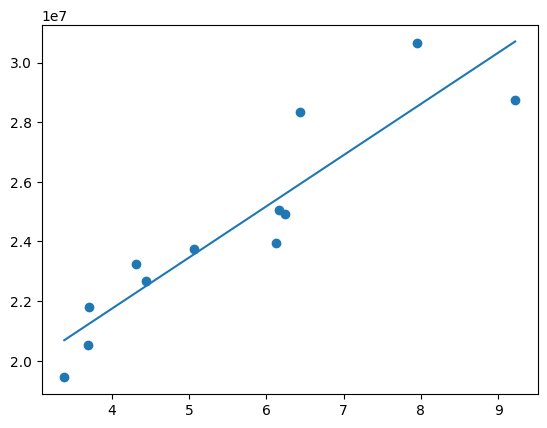

In [153]:


x_exp = np.array(CDD_HDD_L).reshape(-1,1)
y = np.array(CONS_TOT_FIN_SUM_L)

modelo_exp = LinearRegression()
modelo_exp.fit(x, y)

pendiente_exp = modelo.coef_[0]
interseccion_exp = modelo.intercept_

y_pred_exp = modelo_exp.predict(x)

r2_exp = r2_score(y, y_pred)
mse_exp = mean_squared_error(y, y_pred)

print(f"Ecuación: y = {pendiente_exp:.2f}x + {interseccion_exp:.2f}")
print (f"R2: {r2:.2f}")
print (f"MSE: {mse:.2f}")

plt.scatter(x, y)

x_line = np.linspace(x.min(), x.max(), 100).reshape(-1,1)
y_line = modelo.predict(x_line)

plt.plot(x_line, y_line)
plt.show()




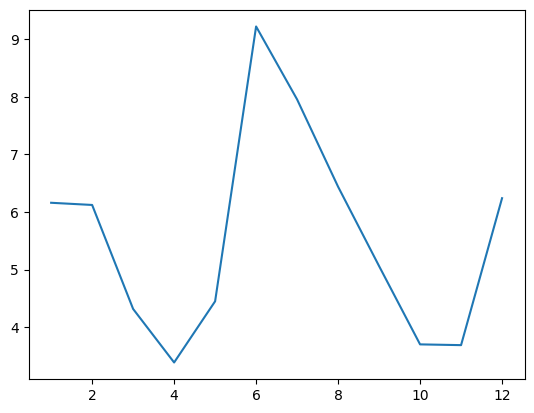

In [146]:
df_chdd_mes

plt.plot(df_chdd_mes['mes'],df_chdd_mes['CCD + HDD'])


In [52]:
'''
#DATAFRAME - 2026



# df_CONS_26 = pd.DataFrame( TABLA DE CONSUMOS 2026)
# df_T_26 = pd.DataFrame( TABLA DE TEMPERATURAS 2026)

#------------|------------#
#------------|------------#
#               DIAS EST



def Cons_Est(beta_c, beta_h, b):
  # Lim_inf = [FECHA LETT ACT]
  # Lim_sup = [FECHA LETT ACT] + df_CONS_26['DIAS ESTIMAR']
  #
  # INT_DIAS_INTERMEDIOS = [for Lim_inf]
  Cons_Est_var = np.array(for b + beta_c *
# df_CONS_26[CONS_EST] = f(CDD,HDD)
'''

"\n#DATAFRAME - 2026\n\n\n\n# df_CONS_26 = pd.DataFrame( TABLA DE CONSUMOS 2026)\n# df_T_26 = pd.DataFrame( TABLA DE TEMPERATURAS 2026)\n\n#------------|------------#\n#------------|------------#\n#               DIAS EST\n\n\n\ndef Cons_Est(beta_c, beta_h, b):\n  # Lim_inf = [FECHA LETT ACT]\n  # Lim_sup = [FECHA LETT ACT] + df_CONS_26['DIAS ESTIMAR']\n  #\n  # INT_DIAS_INTERMEDIOS = [for Lim_inf]\n  Cons_Est_var = np.array(for b + beta_c *\n# df_CONS_26[CONS_EST] = f(CDD,HDD)\n"

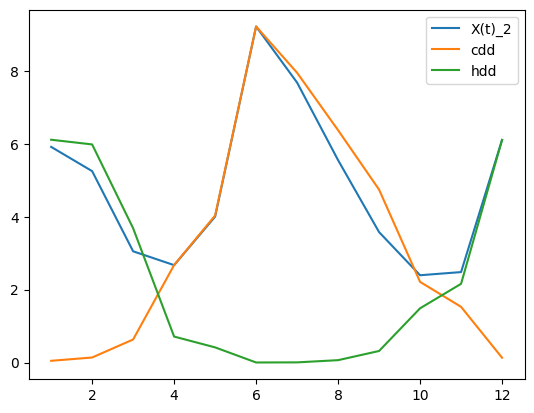

In [154]:
df_chdd_mes['X(t)_1']=df_chdd_mes['CCD + HDD']*np.sin(12/(2*np.pi)*(df_chdd_mes['mes']+1))
df_chdd_mes['X(t)_2']=np.abs(df_chdd_mes['hdd']*np.cos((((np.pi)/12)*(df_chdd_mes['mes'])))) + np.abs(df_chdd_mes['cdd']*np.sin((((np.pi)/12)*(df_chdd_mes['mes']))))


plt.plot(df_chdd_mes['mes'],df_chdd_mes['X(t)_2'])

plt.plot(df_chdd_mes['mes'],df_chdd_mes['cdd'])
plt.plot(df_chdd_mes['mes'],df_chdd_mes['hdd'])

plt.legend(['X(t)_2','cdd','hdd'])


In [148]:
df_chdd_mes

,mes,hdd,cdd,CCD + HDD,X1,X2,X(t)_1,X(t)_2
0,1,6.112500,0.047043,6.159543,1.048167,451.465970,-3.864095,5.916397
1,2,5.983780,0.137798,6.121577,1.147743,396.937867,-3.218476,5.251004
2,3,3.683468,0.631989,4.315457,1.881349,39.784116,4.216519,3.051489
3,4,0.712083,2.674167,3.386250,14.500261,2.038233,-0.420562,2.671938
4,5,0.415323,4.033065,4.448387,56.433588,1.514859,-3.978890,4.003135
5,6,0.001250,9.219722,9.220972,10094.259978,1.001251,6.631687,9.219722
6,7,0.004167,7.950134,7.954301,2835.956102,1.004175,3.309326,7.680319
7,8,0.064785,6.373656,6.438441,586.197002,1.066930,-6.412368,5.552140
8,9,0.316528,4.743889,5.060417,114.880090,1.372354,1.247246,3.578255
9,10,1.487500,2.213038,3.700538,9.143449,4.426017,3.078833,2.394732


In [149]:
X2_L = df_chdd_mes['X(t)_2'].tolist()

df_modelo_ondas = pd.DataFrame({'X':X2_L, 'Y':CONS_TOT_FIN_SUM_L})


X_sin = np.array(df_modelo_ondas['X'].to_list()).reshape(-1,1)
y_sin = np.array(df_modelo_ondas['Y'].to_list())
y_2 = np.array(CONS_TOT_FIN_SUM_L)

modelo_sin = LinearRegression()
modelo_sin.fit(X_sin, y_sin)

pendiente_sin = modelo_sin.coef_[0]
interseccion_sin = modelo_sin.intercept_

y_pred_sin = modelo_sin.predict(X_sin)

r2_sin = r2_score(y_2, y_pred_sin)
mse_sin = mean_squared_error(y_2, y_pred_sin)

print(f"Ecuación: y = {pendiente_sin:.2f}x + {interseccion_sin:.2f}")
print (f"R2: {r2_sin:.2f}")
print (f"MSE: {mse_sin:.2f}")


Ecuación: y = 1362551.78x + 17842767.53
R2: 0.77
MSE: 2373796541926.00


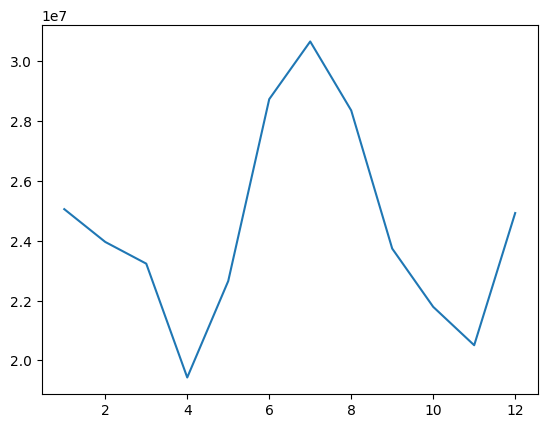

In [150]:
CONS_TOT_FIN_SUM_2 = CONS_TOT_FIN_SUM.reset_index()
plt.plot(CONS_TOT_FIN_SUM_2['REFERENCIA'],CONS_TOT_FIN_SUM_2['CONSUMO TOTAL FINAL'])




In [42]:
df_junio = df[df['REFERENCIA']==202506]
df_junio

,ID,PLAN,GRUPPO,TARIFA DETALLE,FECHA ACTIVACION,TOTAL ACTIVA,FECHA LETT ANT,FECHA LETT ACT,DIAS LEIDOS,PROMEDIO CONSUMO,...,FACTOR ESTACIONAL,ENERGIA MEDIDORES,CONSUMO ESTIMADO,CONSUMO TOTAL FINAL,REFERENCIA,REAL MES CALCULADO,REAL ACUMULADO ANO,TOTAL BALANCE ANO,AJUSTE,ENERGIA ENTREGADA
